# Getting Started Guide 2

This notebook compares the proposed semi-supervised clustering method against a few baseline clustering methods on the same dataset.

It is designed to help answer three practical questions:
- what the raw cluster assignments look like
- how sensitive a density-based baseline such as DBSCAN is to parameter choice
- how evaluation changes when a method is allowed to reject points as anomalies or leave them unassigned

Because the synthetic data and sparse seeds are random, metric values can move around noticeably from run to run. Visual inspection is therefore worth doing alongside any metric table.

## Imports And Setup

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from kneed import KneeLocator
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore", message="Tight layout not applied.*")

notebook_dir = Path.cwd()
root_path = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

In [2]:
from evaluation.clustering_methods import (
    dbscan_clustering,
    kmeans_clustering,
    novel_clustering,
    seeded_k_means_clustering,
)
from utilities.evaluation_metrics import (
    compute_ari,
    compute_fmi,
    compute_nmi,
    compute_purity,
    compute_v_measure,
    evaluate_prediction_scopes,
)
from utilities.generate_load_data import load_dataset
from utilities.plotting import plot_clusters

## Choose A Dataset Configuration

For this notebook, you usually only need to change `dataset_name`.
The other parameters are filled in automatically from the small preset table below so the notebook remains easy to use.

In [3]:
dataset_presets = {
    "1d_simple": {
        "random_seed": 43,
        "k": 3,
        "percent_labelled": 0.03,
        "standardise": False,
    },
    "1d_gauss": {
        "random_seed": 43,
        "k": 3,
        "percent_labelled": 0.002,
        "standardise": False,
    },
    "2d_gauss": {
        "random_seed": 43,
        "k": 8,
        "percent_labelled": 0.01,
        "standardise": False,
    },
}

dataset_name = "2d_gauss"  # Options: "1d_simple",
#                              "1d_gauss",
#                              "2d_gauss"

selected_cfg = dataset_presets[dataset_name]
random_seed = selected_cfg["random_seed"]
k = selected_cfg["k"]
percent_labelled = selected_cfg["percent_labelled"]
standardise = selected_cfg["standardise"]

pd.Series(
    {
        "dataset_name": dataset_name,
        "random_seed": random_seed,
        "k": k,
        "percent_labelled": percent_labelled,
        "standardise": standardise,
    }
)

dataset_name        2d_gauss
random_seed               43
k                          8
percent_labelled        0.01
standardise            False
dtype: object

## Load The Data

In [4]:
df, num_clusters, plot_title, feature_columns = load_dataset(
    dataset_name=dataset_name,
    random_seed=random_seed,
    k=k,
    percent_labelled=percent_labelled,
    standardise=standardise,
)

dataset_summary = pd.Series(
    {
        "dataset": dataset_name,
        "n_examples": len(df),
        "n_features": len(feature_columns),
        "n_clusters_requested": num_clusters,
        "n_seeded_points": int((df["y_live"] != -1).sum()),
        "seed_fraction": round((df["y_live"] != -1).mean(), 4),
        "feature_columns": ", ".join(feature_columns),
    }
)

dataset_summary

dataset                 2d_gauss
n_examples                 10300
n_features                     2
n_clusters_requested           8
n_seeded_points              100
seed_fraction             0.0097
feature_columns           f0, f1
dtype: object

In [5]:
df.head()

,f0,f1,y_true,y_live
0,-3.577115,7.409740,2,-1
1,-7.496777,2.719674,0,-1
2,-3.554719,7.132534,2,-1
3,-6.976751,5.938354,4,-1
4,-5.527477,-8.477739,6,-1


## Visualise The Ground Truth And The Sparse Seed Labels

### Ground Truth

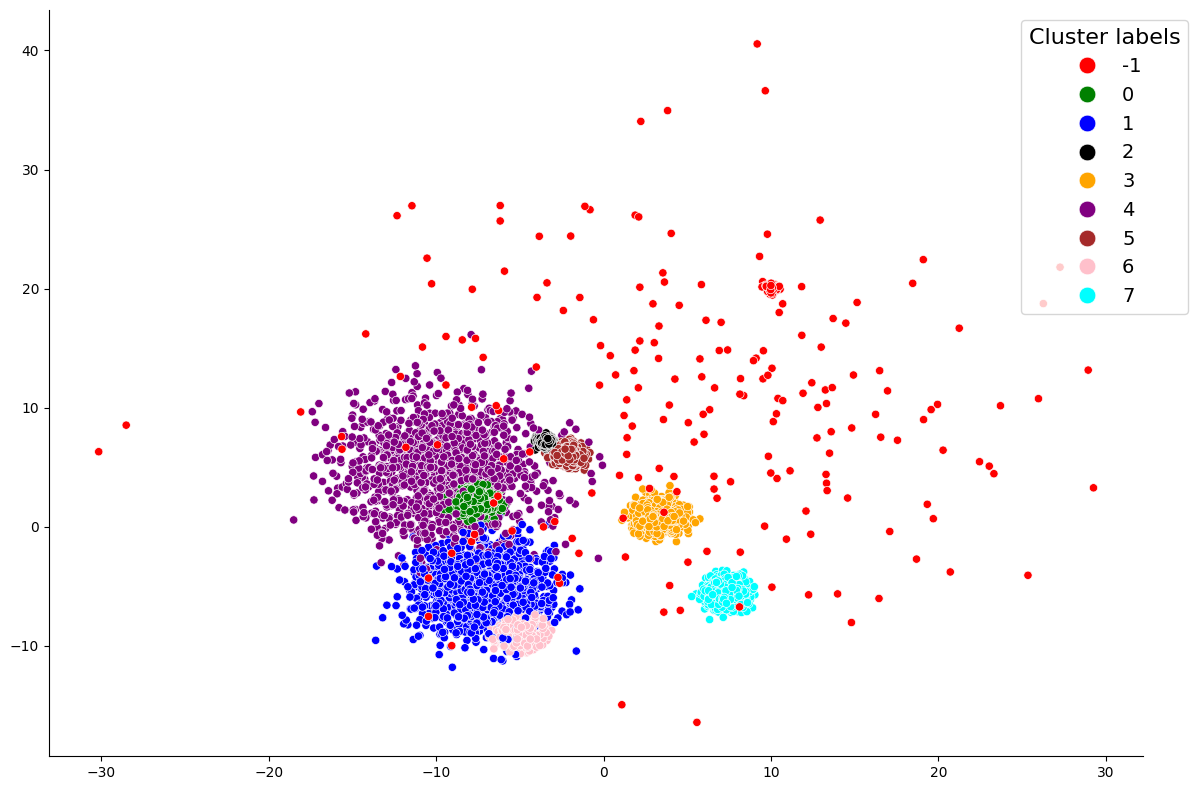

In [6]:
display(Markdown("### Ground Truth"))
plot_clusters(
    df,
    feature_columns,
    label_column="y_true",
    show_seeds_only=False,
);

### Seed Labels

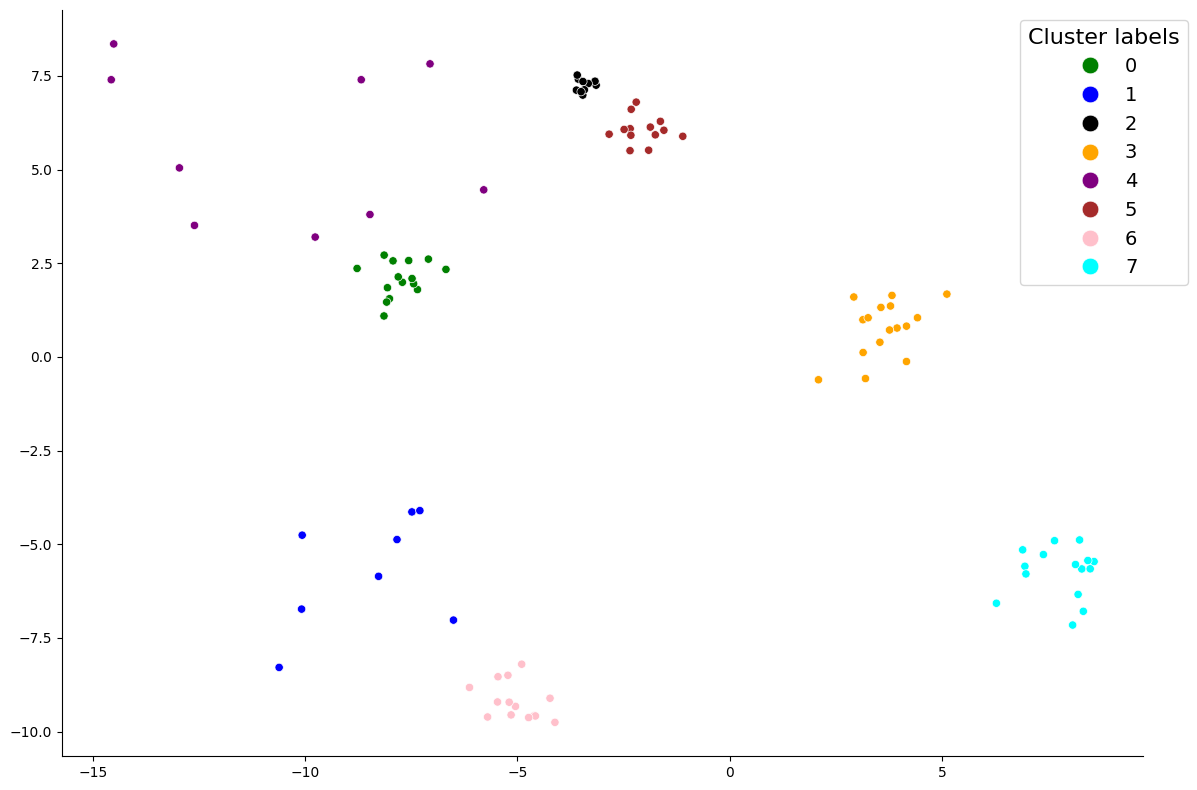

In [7]:
display(Markdown("### Seed Labels"))
plot_clusters(
    df,
    feature_columns,
    label_column="y_live",
    show_seeds_only=True,
);

## Optional: Estimate A Candidate `eps` For DBSCAN

This is only a heuristic. The suggested knee point can differ quite a bit from the value that gives a visually sensible clustering.

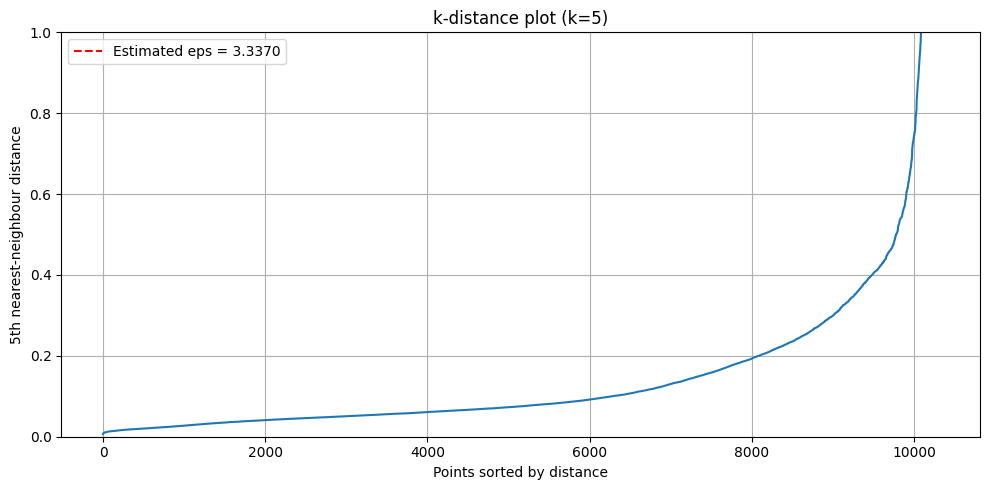

Estimated eps: 3.3370490923460903


In [8]:
def estimate_eps(df, feature_columns, k=5, zoom_ymax=2.0, detect_knee=True):
    X = df[feature_columns].to_numpy()
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, k - 1])

    plt.figure(figsize=(10, 5))
    plt.plot(k_distances)
    plt.ylim(0, zoom_ymax)
    plt.title(f"k-distance plot (k={k})")
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{k}th nearest-neighbour distance")

    eps = None
    if detect_knee:
        knee_locator = KneeLocator(
            range(len(k_distances)),
            k_distances,
            curve="convex",
            direction="increasing",
        )
        if knee_locator.knee is not None:
            eps = k_distances[knee_locator.knee]
            plt.axhline(y=eps, color="red", linestyle="--", label=f"Estimated eps = {eps:.4f}")
            plt.legend()

    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return eps

estimated_eps = estimate_eps(df, feature_columns=feature_columns, k=5, zoom_ymax=1.0, detect_knee=True)
print(f"Estimated eps: {estimated_eps}")

## Run Several Clustering Methods On The Same Data

In [9]:
def run_method(method_name, df, feature_columns, num_clusters):
    df_copy = df.copy()

    if method_name == "novel_method":
        result_df = novel_clustering(
            df_copy,
            feature_columns,
            seeds="y_live",
        )
    elif method_name == "SeededKMeans":
        result_df = seeded_k_means_clustering(
            df_copy,
            feature_columns,
            target_column="y_true",
            seeds="y_live",
            n_clusters=num_clusters,
            random_state=0,
            remap_labels=False,
        )
    elif method_name == "KMeans":
        result_df = kmeans_clustering(
            df_copy,
            feature_columns,
            target_column="y_true",
            n_clusters=num_clusters,
            random_state=0,
            remap_labels=False,
        )
    elif method_name == "DBSCAN":
        result_df = dbscan_clustering(
            df_copy,
            feature_columns,
            target_column="y_true",
            eps=0.3,
            min_samples=4,
            remap_labels=False,
        )
    else:
        raise ValueError(f"Unsupported method: {method_name}")

    return result_df

methods_to_compare = ["novel_method", "SeededKMeans", "KMeans", "DBSCAN"]

In [10]:
df_results = df.copy()
runtime_rows = []
result_frames = {}

for method_name in methods_to_compare:
    start = time.perf_counter()
    result_df = run_method(method_name, df, feature_columns, num_clusters)
    elapsed = time.perf_counter() - start

    result_frames[method_name] = result_df
    df_results[method_name] = result_df[method_name]
    runtime_rows.append(
        {
            "Algorithm": method_name,
            "Runtime (s)": round(elapsed, 3),
        }
    )

runtime_df = pd.DataFrame(runtime_rows).sort_values("Algorithm").reset_index(drop=True)
runtime_df

,Algorithm,Runtime (s)
0,DBSCAN,0.060
1,KMeans,0.012
2,SeededKMeans,0.061
3,novel_method,0.184


## Compare The Predicted Clusterings Visually

### Proposed Method

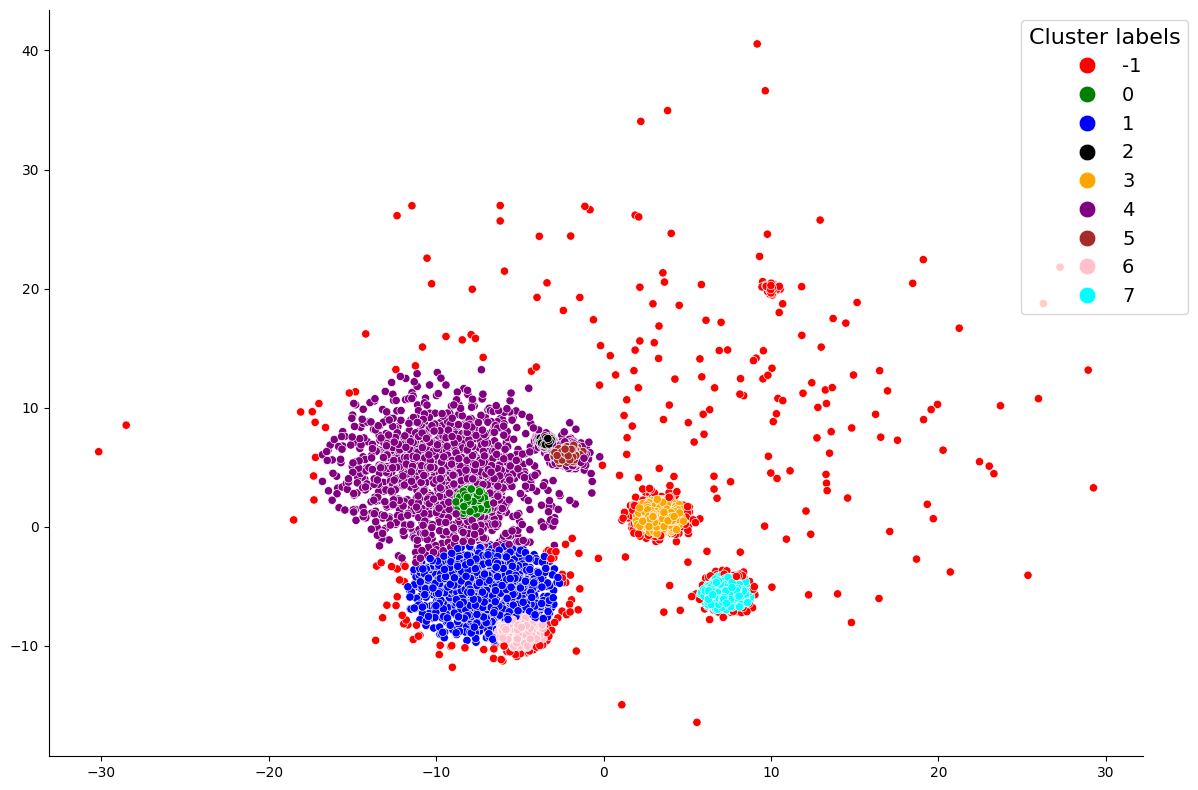

### Seeded K-Means

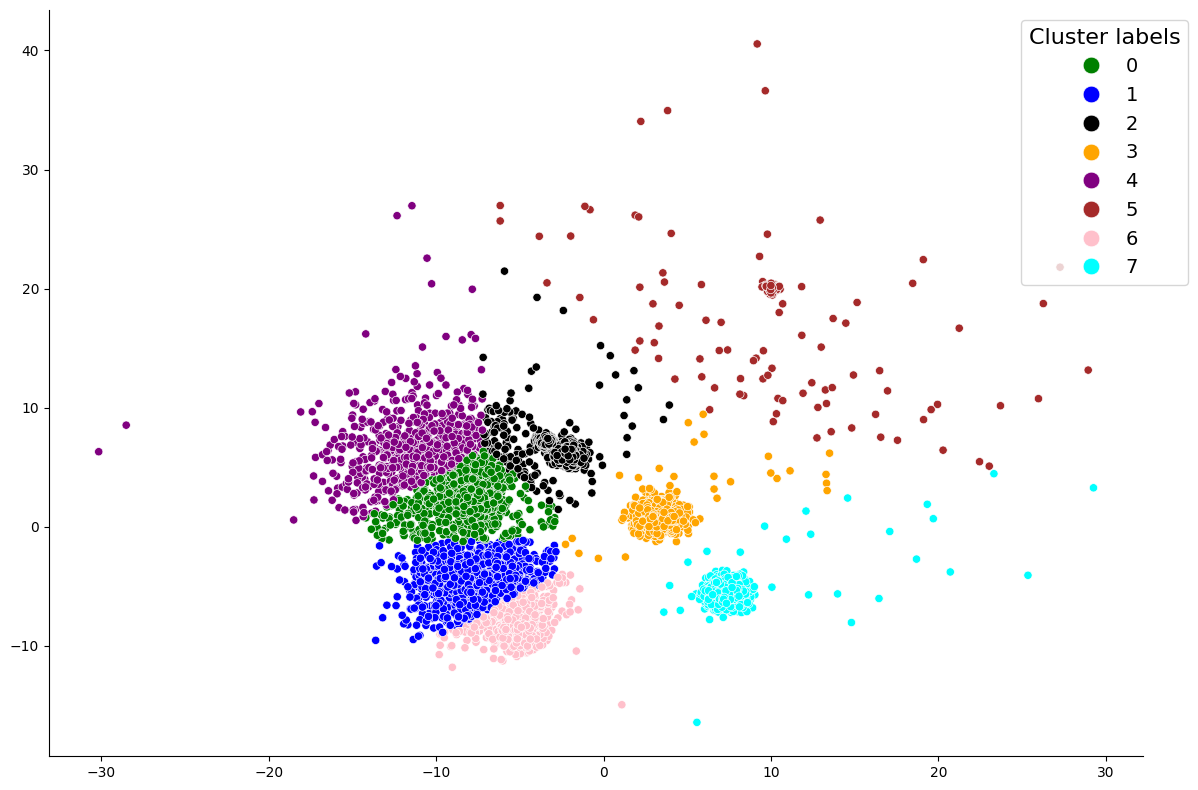

### K-Means

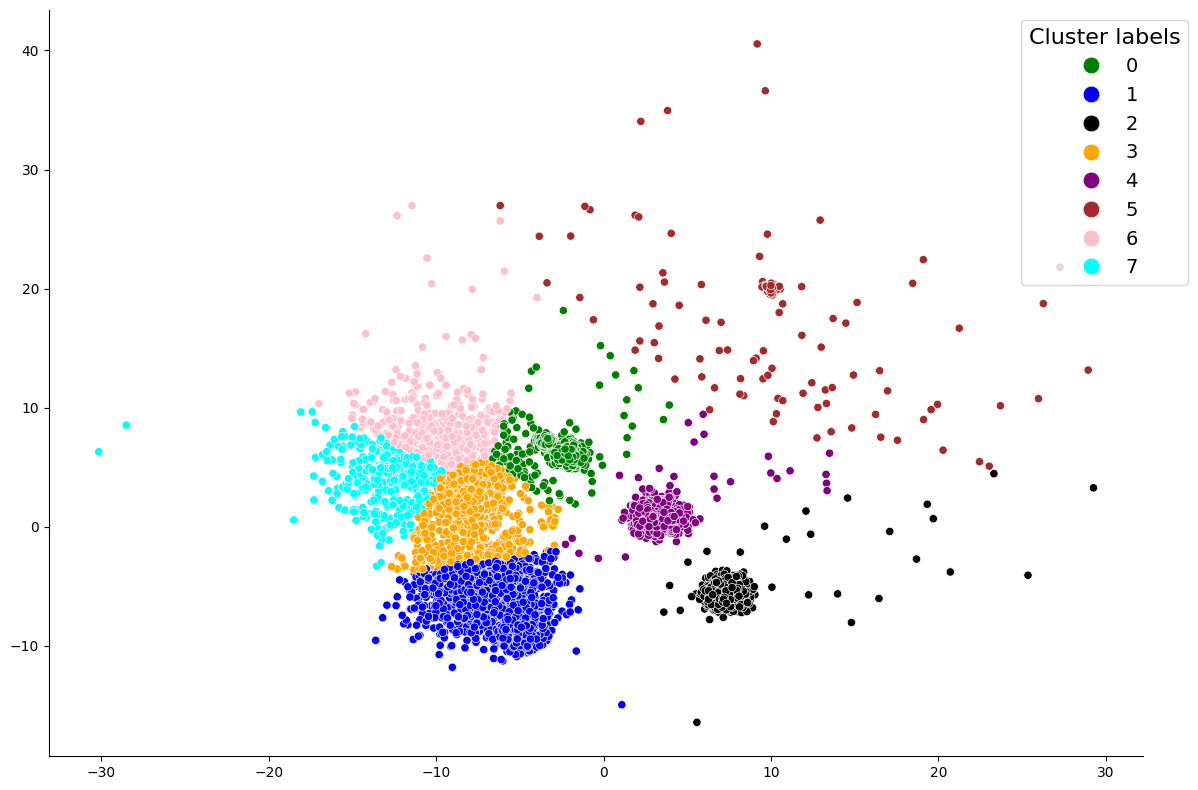

### DBSCAN

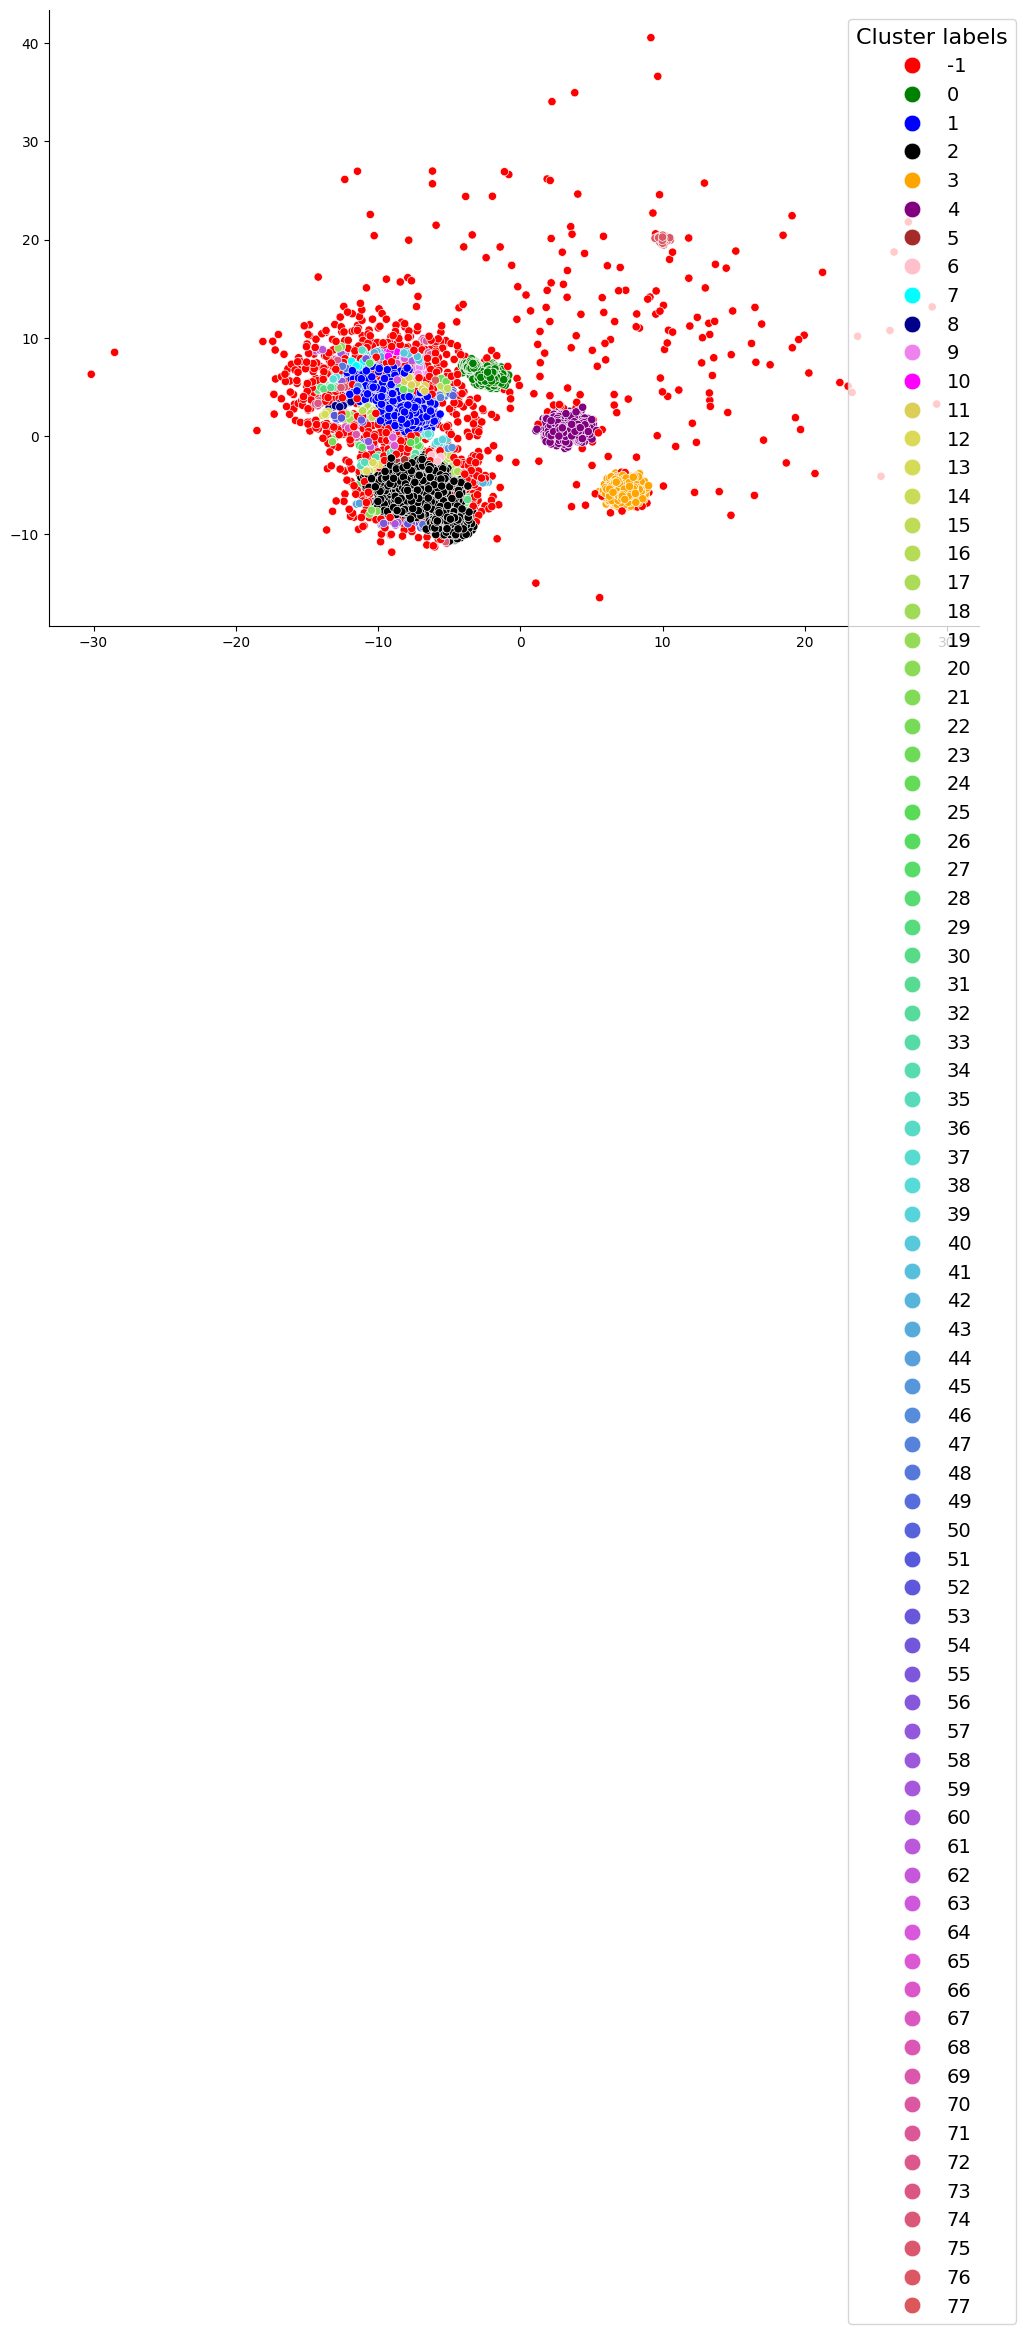

In [11]:
pretty_method_names = {
    "novel_method": "Proposed Method",
    "SeededKMeans": "Seeded K-Means",
    "KMeans": "K-Means",
    "DBSCAN": "DBSCAN",
}

for method_name in methods_to_compare:
    display(Markdown(f"### {pretty_method_names.get(method_name, method_name)}"))
    plot_clusters(
        df_results,
        feature_columns,
        label_column=method_name,
        show_seeds_only=False,
    )

## Inspect The Label Counts

For anomaly-aware methods, this helps separate ordinary clustering behaviour from explicit rejection behaviour.

In [12]:
label_counts = {}
for column in ["y_true", "y_live"] + methods_to_compare:
    label_counts[column] = df_results[column].value_counts().sort_index()

label_count_df = pd.DataFrame(label_counts).fillna(0).astype(int)
label_count_df

,y_true,y_live,novel_method,SeededKMeans,KMeans,DBSCAN
-1,300,10200,527,0,0,782
0,1250,15,1116,1767,2615,2503
1,1250,8,1170,1009,2357,1701
2,1250,10,1097,2648,1276,2216
3,1250,16,1149,1279,1819,1239
...,...,...,...,...,...,...
73,0,0,0,0,0,5
74,0,0,0,0,0,3
75,0,0,0,0,0,4
76,0,0,0,0,0,100


## Evaluate The Clusterings

The table below reports both:
- `(... retained)`: the score on points retained by the method after dropping predicted `-1`
- `(... full)`: the score on the full dataset, treating `-1` as an anomaly or unassigned label

For methods that do not reject points, the retained and full scores will usually be the same.

In [13]:
supervised_metrics = {
    "Purity": {"fn": compute_purity, "requires_gt": True},
    "V-Measure": {"fn": compute_v_measure, "requires_gt": True},
    "NMI": {"fn": compute_nmi, "requires_gt": True},
    "ARI": {"fn": compute_ari, "requires_gt": True},
    "FMI": {"fn": compute_fmi, "requires_gt": True},
}

In [16]:
evaluation_rows = []

for method_name in methods_to_compare:
    scores = evaluate_prediction_scopes(
        df=df_results,
        metrics_dict=supervised_metrics,
        pred_col=method_name,
        feature_columns=feature_columns,
        true_col="y_true",
        outlier_label=-1,
    )
    evaluation_rows.append({"Algorithm": method_name, **scores})

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df.insert(1, "Dataset", dataset_name)


In [15]:
metric_cols = [
    col for col in evaluation_df.columns
    if col not in {"Algorithm", "Dataset", "Rejected Count"}
]

styled_eval = (
    evaluation_df.style
    .highlight_max(subset=metric_cols, axis=0, props="font-weight: bold;")
    .background_gradient(subset=metric_cols, cmap="RdYlGn", axis=0)
    .format({"Rejected Count": "{:.0f}", "Rejection Rate": "{:.2%}"}, na_rep="--", precision=4)
)

styled_eval

,Algorithm,Dataset,Rejected Count,Rejection Rate,Purity (retained),Purity (full),V-Measure (retained),V-Measure (full),NMI (retained),NMI (full),ARI (retained),ARI (full),FMI (retained),FMI (full)
0,novel_method,2d_gauss,527,5.12%,0.9332,0.9097,0.8871,0.8519,0.8871,0.8519,0.8516,0.8194,0.8703,0.8407
1,SeededKMeans,2d_gauss,0,0.00%,0.7821,0.7778,0.8397,0.8265,0.8397,0.8265,0.7100,0.7020,0.7596,0.7516
2,KMeans,2d_gauss,0,0.00%,0.6988,0.6968,0.8070,0.7955,0.8070,0.7955,0.6491,0.6437,0.7172,0.7108
3,DBSCAN,2d_gauss,782,7.59%,0.7130,0.7009,0.8053,0.7697,0.8053,0.7697,0.6880,0.6539,0.7523,0.7124


## Suggested Interpretation

When comparing the methods, look for a combination of:
- visually coherent clusters
- reasonable rejection behaviour for anomaly-aware methods
- stable retained-vs-full performance

If a method has a strong retained score but a much weaker full-dataset score, that usually means its coverage behaviour matters and should be interpreted explicitly rather than ignored.